# Assignment-3 COMP-5970 Jacob Murrah
## README
In this assignment, you will capture your own images using a smartphone
and implement key components of classical 3D vision: stereo matching and
structure-from-motion (SfM). This hands-on task will help you appreciate
how camera placement, motion, and calibration influence 3D reconstruction
in practice.

## Dependencies
- **Python 3.x**
- **numpy**
- **matplotlib**
- **opencv-python**

*Note: If you are running this notebook in Google Colab, all the required packages are pre-installed.*

## Instructions
1. **Run All Cells:** Please click on \"Runtime\" > \"Run all\" to execute the entire notebook sequentially.
2. **Review the Outputs:** The notebook is organized into several sections. Ensure that all cells run without errors.

## GenAI Usage Declaration
GenAI was used to explain the various equations in stereo vision and structure from motion. I specifically used GenAI to understand the intrinsic matrix, essential matrix, focal point, baseline, rotation, translation, pose, disparity maps, and triangulation.

## Statement of Contribution
This was an individual project and I did everything in it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

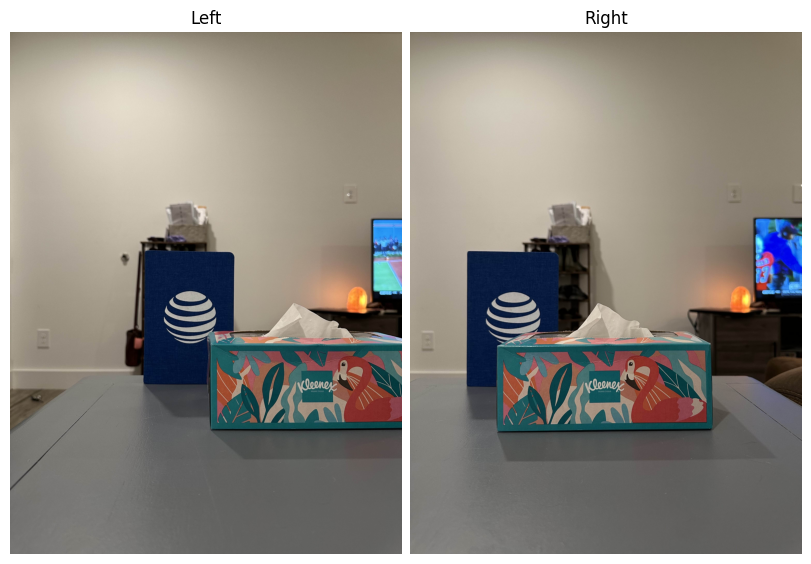

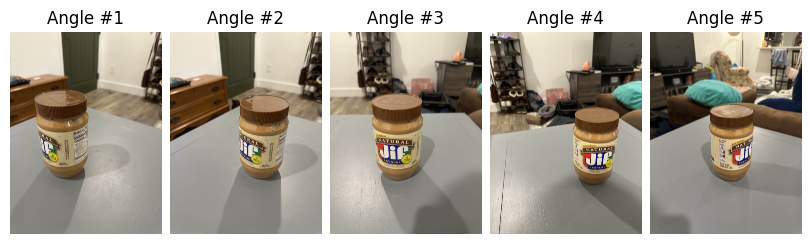

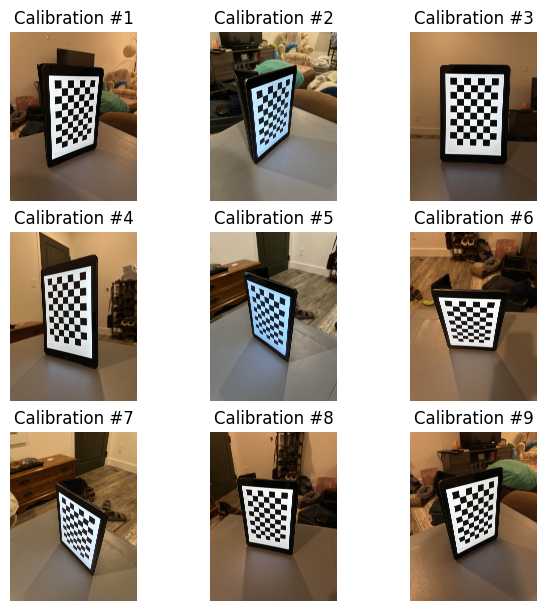

In [2]:
# loading images
ORIGINAL_IMG_SIZE = (3024, 4032) # (width, height)
IMG_SIZE = (567, 756)  # (width, height)

# Stereo Vision Images
left_img_bgr = cv2.imread('left.jpg')
right_img_bgr = cv2.imread('right.jpg')
fig1, axes1 = plt.subplots(1, 2, figsize=(8, 6), constrained_layout=True)
axes1[0].imshow(cv2.cvtColor(left_img_bgr, cv2.COLOR_BGR2RGB))
axes1[0].set_title('Left')
axes1[0].axis('off')
axes1[1].imshow(cv2.cvtColor(right_img_bgr, cv2.COLOR_BGR2RGB))
axes1[1].set_title('Right')
axes1[1].axis('off')

# Structure from Motion images
angle1_img_bgr = cv2.imread('angle1.jpg')
angle2_img_bgr = cv2.imread('angle2.jpg')
angle3_img_bgr = cv2.imread('angle3.jpg')
angle4_img_bgr = cv2.imread('angle4.jpg')
angle5_img_bgr = cv2.imread('angle5.jpg')
fig2, axes2 = plt.subplots(1, 5, figsize=(8, 6), constrained_layout=True)
axes2[0].imshow(cv2.cvtColor(angle1_img_bgr, cv2.COLOR_BGR2RGB))
axes2[0].set_title('Angle #1')
axes2[0].axis('off')
axes2[1].imshow(cv2.cvtColor(angle2_img_bgr, cv2.COLOR_BGR2RGB))
axes2[1].set_title('Angle #2')
axes2[1].axis('off')
axes2[2].imshow(cv2.cvtColor(angle3_img_bgr, cv2.COLOR_BGR2RGB))
axes2[2].set_title('Angle #3')
axes2[2].axis('off')
axes2[3].imshow(cv2.cvtColor(angle4_img_bgr, cv2.COLOR_BGR2RGB))
axes2[3].set_title('Angle #4')
axes2[3].axis('off')
axes2[4].imshow(cv2.cvtColor(angle5_img_bgr, cv2.COLOR_BGR2RGB))
axes2[4].set_title('Angle #5')
axes2[4].axis('off')

# Calibration images
calibration1_img_bgr = cv2.imread('calibration1.jpg')
calibration2_img_bgr = cv2.imread('calibration2.jpg')
calibration3_img_bgr = cv2.imread('calibration3.jpg')
calibration4_img_bgr = cv2.imread('calibration4.jpg')
calibration5_img_bgr = cv2.imread('calibration5.jpg')
calibration6_img_bgr = cv2.imread('calibration6.jpg')
calibration7_img_bgr = cv2.imread('calibration7.jpg')
calibration8_img_bgr = cv2.imread('calibration8.jpg')
calibration9_img_bgr = cv2.imread('calibration9.jpg')

fig_cal, axes_cal = plt.subplots(3, 3, figsize=(6, 6), constrained_layout=True)
calibration_imgs_rgb = [
    calibration1_img_bgr, calibration2_img_bgr, calibration3_img_bgr,
    calibration4_img_bgr, calibration5_img_bgr, calibration6_img_bgr,
    calibration7_img_bgr, calibration8_img_bgr, calibration9_img_bgr
]
for ax, img, idx in zip(axes_cal.flatten(), calibration_imgs_rgb, range(1, 10)):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Calibration #{idx}')
    ax.axis('off')

plt.show()

In [3]:
# Utility function used in all tasks

def draw_epipolar_lines(img, F, pts, which='left'):
    lines = cv2.computeCorrespondEpilines(
        pts.reshape(-1,1,2), 2 if which=='left' else 1, F
    )
    lines = lines.reshape(-1,3)

    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for r in lines:
        color = tuple(np.random.randint(0, 255, 3).tolist())
        x0, y0 = map(int, [0, -r[2]/r[1]])
        x1, y1 = map(int, [img.shape[1], -(r[2]+r[0]*img.shape[1])/r[1]])
        img_color = cv2.line(img_color, (x0,y0), (x1,y1), color, 1)

    return img_color

# Task 1) Stereo Vision
Capture two stereo images of a tabletop scene and compute a disparity map.

## Description of Approach
In stereo vision we use two photos to capture depth in a scene and create a disparity map. Intuitively you can think of this like how human eyes capture depth. I know that we first need to find all the keypoints in both images and find the matches across images. I use the ORB detector to find these matches and only keep the strongest correspondences across images. I then estimate the fundamental matrix in order to constrain the match search space between the two images. Basically if a match does not fall along the epipolar lines created by the fundamental matrix, the match can be discarded as invalid. Once we have the good correspondences that fall along the epipolar lines we can use OpenCV to calculate the disparity map for us.

NOTE: When taking photos I focused on keeping the camera setups parallel to each other. My results with a parallel set up were a lot better than a toed in setup.

APPROXIMATE_BASELINE_DISTANCE = 5.5 inches

In [4]:
APPROXIMATE_BASELINE_DISTANCE = 5.5 # inches

left_img = cv2.resize(cv2.cvtColor(left_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE)
right_img = cv2.resize(cv2.cvtColor(right_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE)

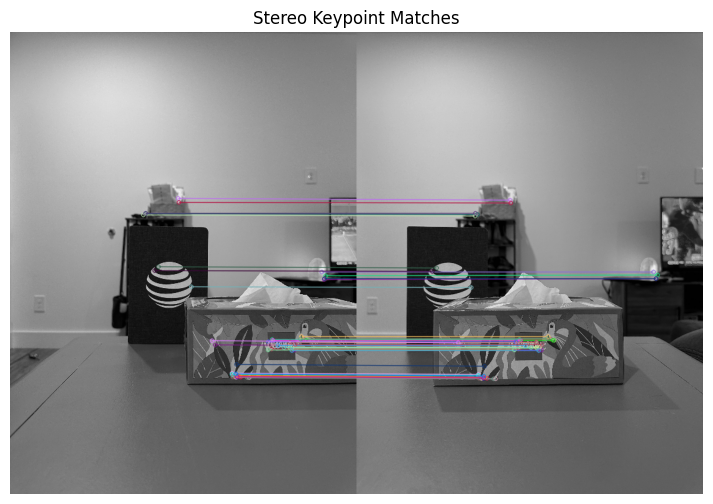

In [5]:
# Task 1 Part 5a. Detect and match features

def match_stereo_keypoints(l_img, r_img):
    # Initialize ORB detector
    orb = cv2.ORB_create()

    # Detect keypoints and compute descriptors
    key_p1, des1 = orb.detectAndCompute(l_img, None)
    key_p2, des2 = orb.detectAndCompute(r_img, None)

    # Match descriptors using BruteForce + Hamming
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    bf_matches = bf.match(des1, des2)
    bf_matches = sorted(bf_matches, key=lambda x: x.distance)

    # Draw first 50 matches
    img_matches = cv2.drawMatches(
        l_img, key_p1, r_img, key_p2, bf_matches[:50], None, flags=2
    )

    # Display
    plt.figure(figsize=(14, 6))
    plt.imshow(img_matches, cmap='gray')
    plt.title('Stereo Keypoint Matches')
    plt.axis('off')
    plt.show()

    return key_p1, key_p2, bf_matches

kp1, kp2, matches = match_stereo_keypoints(
    left_img, right_img
)

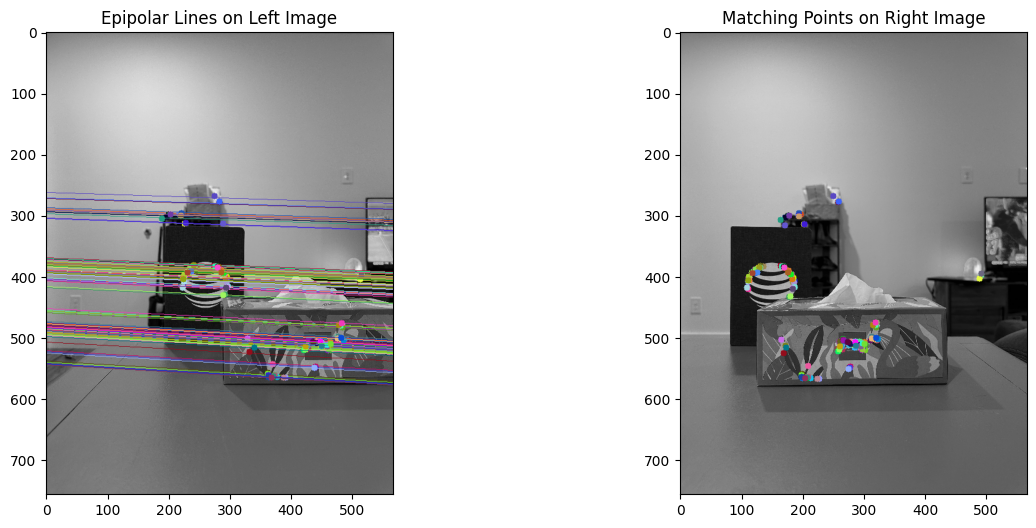

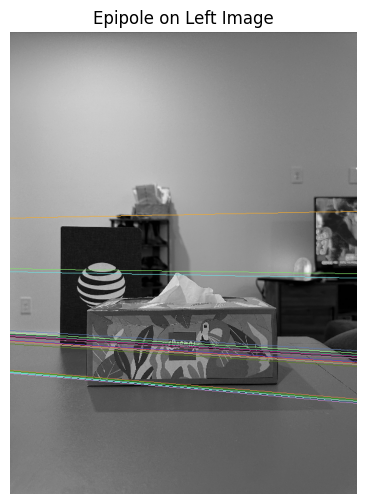

In [6]:
# Task 1 Part 5b. Estimate the fundamental matrix and draw epipolar lines

def estimate_fundamental_matrix_and_draw_epipolar_lines(
    l_img,
    r_img,
    bf_matches,
    key_p1,
    key_p2,
):
    def drawlines(img1, img2, lines, pts_1, pts_2):
        '''
        img1 - image on which we draw the epilines for the points in img2
        lines - corresponding epilines
        '''
        r, c = img1.shape
        img1_color = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
        img2_color = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)
        for r_line, pt1, pt2 in zip(lines, pts_1, pts_2):
            color = tuple(np.random.randint(0,255,3).tolist())
            x0, y0 = map(int, [0, - r_line[2] / r_line[1]])
            x1, y1 = map(int, [c, - (r_line[2] + r_line[0] * c) / r_line[1]])
            img1_color = cv2.line(img1_color, (x0, y0), (x1, y1), color, 1)
            img1_color = cv2.circle(
                img1_color, tuple(np.int32(pt1)), 5, color, -1
            )
            img2_color = cv2.circle(
                img2_color, tuple(np.int32(pt2)), 5, color, -1
            )

        return img1_color, img2_color

    # Get corresponding points
    pts_1 = np.float32([key_p1[m.queryIdx].pt for m in bf_matches])
    pts_2 = np.float32([key_p2[m.trainIdx].pt for m in bf_matches])

    F_mat, mask = cv2.findFundamentalMat(pts_1, pts_2, cv2.FM_RANSAC)

    # Keep inliers only
    pts_1 = pts_1[mask.ravel() == 1]
    pts_2 = pts_2[mask.ravel() == 1]

    # Find epilines in right image for pts1 (from left)
    lines1 = cv2.computeCorrespondEpilines(pts_2.reshape(-1,1,2), 2, F_mat)
    lines1 = lines1.reshape(-1,3)

    img5, img6 = drawlines(l_img, r_img, lines1, pts_1, pts_2)

    # Show results
    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1), plt.imshow(img5), plt.title(
        'Epipolar Lines on Left Image'
    )
    plt.subplot(1,2,2), plt.imshow(img6), plt.title(
        'Matching Points on Right Image'
    )

    # Compute epipole (right camera center projected onto left image)
    U, S, Vt = np.linalg.svd(F_mat.T)
    e_left = Vt[-1]
    e_left = e_left / e_left[2]

    epilines_img = draw_epipolar_lines(r_img, F_mat, pts_2[:30], which='right')

    # Draw the epipole on the left image
    epix, epiy = int(e_left[0]), int(e_left[1])
    epipole_img = epilines_img.copy()
    cv2.circle(epipole_img, (epix, epiy), 6, (0, 0, 255), -1)

    # Plot result
    plt.figure(figsize=(6, 6))
    plt.imshow(epipole_img)
    plt.title('Epipole on Left Image')
    plt.axis("off")
    plt.show()

    return pts_1, pts_2, F_mat

pts1, pts2, F = estimate_fundamental_matrix_and_draw_epipolar_lines(
    left_img, right_img, matches, kp1, kp2
)

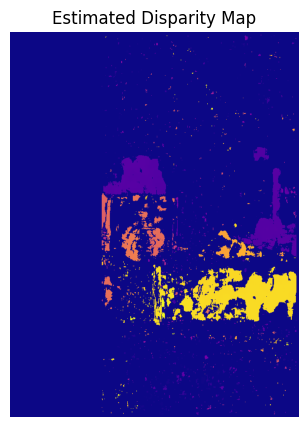

In [7]:
# Task 1 Part 5c. Compute the disparity map

def compute_disparity_map(
    l_img,
    r_img,
    pts_1,
    pts_2,
    F_mat,
):
    # Epipolar constraint: x_r^T F x_l ≈ 0
    for i in range(min(20, len(pts1))):
        x_l = np.array([*pts_1[i], 1])
        x_r = np.array([*pts_2[i], 1])
        error = x_r @ F_mat @ x_l.T

    # Stereo block matcher
    stereo = cv2.StereoBM_create(numDisparities=176, blockSize=11)
    disparity = stereo.compute(l_img, r_img)

    # Normalize disparity for display
    disp_norm = cv2.normalize(
        disparity, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX
    )
    disp_norm = np.uint8(disp_norm)

    # Show disparity map
    plt.figure(figsize=(10, 5))
    plt.imshow(disp_norm, cmap='plasma')
    plt.title('Estimated Disparity Map')
    plt.axis('off')
    plt.show()

compute_disparity_map(left_img, right_img, pts1, pts2, F)

## Task 1 Part 5d. Analyze how baseline distance and camera orientation affect disparity quality.

Answer:
In stereo vision we capture a scene from two different angles. Introducing the 2nd angle allows us to capture depth. The larger the baseline distance, the easier it is to capture the depth in the scene (disparity increases), but it can become more challenging to match the two images since the overlapping region reduces. If the baseline is very small, matching the images is easier, but it is more difficult to measure the depth since disparities are so small. Thus a small baseline can lead to very sensitive disparity mappings and a lower depth resolution.

The camera rotations and tilts directly impact the complexity of the correspondence search between the two images. If the two photos are taken with parallel camera configurations the search is primarily horizontal. If the photos are taken with a toed-in (converging) configuration, the matching is no longer primarily horizontal and the search becomes more complex. Normally this more complex search leads to increased disparity error.

## Task 1 Part 6 Write-up (1–2 paragraphs):

a. How did you ensure camera alignment?

Answer: I used a parallel camera configuration and placed my phone on the same table my items were on. There was a horizonal line on the table the I used to ensure my phone wasn't tilted. I also used where the wall and ceiling intersected and lined this up at the top of my camera view to further ensure I wasnt shifting my camera angle.

NOTE: I reserved more in depth calibration for Task 3.

b. Did the disparity map make sense?

Answer: Somewhat, the closer tissue box was indeed brighter than the notebook. The TV and other things in the background were the darkest. It did not do a good job of completely outlining the objects but it is correctly identifying depth.

c. What happens if the baseline is very small or too large?

Answer: If the baseline is very small there isn't enough disparity between the images and it becomes difficult to measure depth. If the baseline is too large it becomes difficult to find matches between the images since the overlapping regions reduce.

# Task 2) Structure from Motion
Capture a sequence of 3–5 images of a small object or your workspace from
different viewpoints and reconstruct the 3D structure via SfM.

## Description of Approach
In structure from motion we can recreate an object by capturing the same object from multiple angles. In order to connect the multiple images we must 'chain together' the images. Between each left and right image pair (consecutive images) we must do the following. First we detect and match keypoints between images. We use SIFT to do this since the images have rotation and scale differences between them. Since I have not calibrated my camera yet I just estimate K. Next we need recover the relative motion of the camera in relation to the object. To do this we need the essential matrix to estimate the rotation and translation that occurs between image pairs. Once we have the camera poses we can triangulate the points that match between the image pairs and use this to create a 3D point cloud as well as the camera trajectory.

NOTE: When taking my photos I focused on keeping a consistent height and making sure there was enough overlapping features present in consecutive images.

In [8]:
def extract_and_match_features(img1, img2):
		sift = cv2.SIFT_create()
		kp_1, des_1 = sift.detectAndCompute(img1, None)
		kp_2, des_2 = sift.detectAndCompute(img2, None)

		# FLANN matcher
		index_params = dict(algorithm=1, trees=5)
		search_params = dict()
		flann = cv2.FlannBasedMatcher(index_params, search_params)
		s_matches = flann.knnMatch(des_1, des_2, k=2)

		# Lowe's ratio test
		good = []
		pts_1, pts_2 = [], []
		for m, n in s_matches:
				if m.distance < 0.8 * n.distance: # Relaxed ratio for density
						good.append(m)
						pts_1.append(kp_1[m.queryIdx].pt)
						pts_2.append(kp_2[m.trainIdx].pt)

		return np.array(pts_1), np.array(pts_2)

def estimate_K(image):
		h, w = image.shape
		# Assume a 60-degree Field of View (FOV)
		FOV_rad = np.deg2rad(60)
		focal_length_approx = max(w, h) / (2 * np.tan(FOV_rad / 2))

		K_est = np.array([
			[focal_length_approx, 0, w / 2],
			[0, focal_length_approx, h / 2],
			[0, 0, 1]
		])

		return K_est

def plot_trajectory(trajectory):
    traj = np.array([pose[:3,3] for pose in trajectory])
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(traj[:,0], traj[:,1], traj[:,2], 'bo-')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title("Camera Trajectory")
    plt.show()

def plot_structure(structure):
    all_pts = np.vstack(structure) if len(structure) > 0 else np.empty((0,3))
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(all_pts[:,0], all_pts[:,1], all_pts[:,2], s=1, c='g')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title("3D Structure")
    plt.show()

In [9]:
def run_sfm(images, k=None):
    K_mat = k if k is not None else estimate_K(images[0])

    trajectory = [np.eye(4)] # Initial pose (identity)
    structure = []

    # extracting across consecutive pairs
    for i in range(len(images) - 1):
        img1, img2 = images[i], images[i+1]

        pts1, pts2 = extract_and_match_features(img1, img2)

        # 1. Calculate Fundamental Matrix (F) - UNCALIBRATED GEOMETRY
        F, F_mask = cv2.findFundamentalMat(
            pts1,
            pts2,
            method=cv2.FM_RANSAC,
            ransacReprojThreshold=1.0,
            confidence=0.999
        )

        # Epipolar lines visualization
        inliers1 = pts1[F_mask.ravel() == 1]
        inliers2 = pts2[F_mask.ravel() == 1]
        img1_epilines = draw_epipolar_lines(
            img1, F, inliers2, which='left'
        )
        img2_epilines = draw_epipolar_lines(
            img2, F, inliers1, which='right'
        )
        plt.figure(figsize=(15, 6))
        plt.subplot(1, 2, 1), plt.imshow(img1_epilines), plt.title(
            'Epipolar Lines on Left Image'
        )
        plt.subplot(1, 2, 2), plt.imshow(img2_epilines), plt.title(
            'Epipolar Lines on Right Image'
        )
        plt.show()

        # 2. Calculate Essential Matrix (E) and Recover Pose (R, t)
        # E requires K, which we use the estimated K_mat for.
        E, E_mask = cv2.findEssentialMat(
            pts1, pts2, K_mat, method=cv2.RANSAC, prob=0.999, threshold=1.0
        )

        _, R, t, _ = cv2.recoverPose(E, pts1, pts2, K_mat)

        # Compose current pose (R, t) into the global trajectory
        last_pose = trajectory[-1]
        cur_pose = np.eye(4)
        cur_pose[:3, :3] = R
        cur_pose[:3, 3] = t.flatten()
        trajectory.append(last_pose @ cur_pose)

        # 3. Triangulate Points
        # Use the estimated K for the projection matrices
        proj1 = K_mat @ np.eye(3, 4)
        proj2 = K_mat @ np.hstack((R, t))

        # Use the points that were considered inliers for both E and F
        valid_pts1 = pts1[E_mask.ravel()==1]
        valid_pts2 = pts2[E_mask.ravel()==1]

        pts4D = cv2.triangulatePoints(proj1, proj2, valid_pts1.T, valid_pts2.T)
        pts3D = (pts4D / pts4D[3])[:3].T

        # 4. Cheirality Check (Point Filtering)
        # Filter points that are behind either camera
        pose2_RT = np.hstack((R, t))
        pts3D_h = np.hstack((pts3D, np.ones((pts3D.shape[0], 1))))

        # Transform points to camera 2 coordinate system
        pts3D_cam2 = (pose2_RT @ pts3D_h.T).T

        # Valid points must have positive Z in both camera frames
        valid_idx = (pts3D[:, 2] > 0) & (pts3D_cam2[:, 2] > 0)

        structure.append(pts3D[valid_idx])

    return trajectory, structure

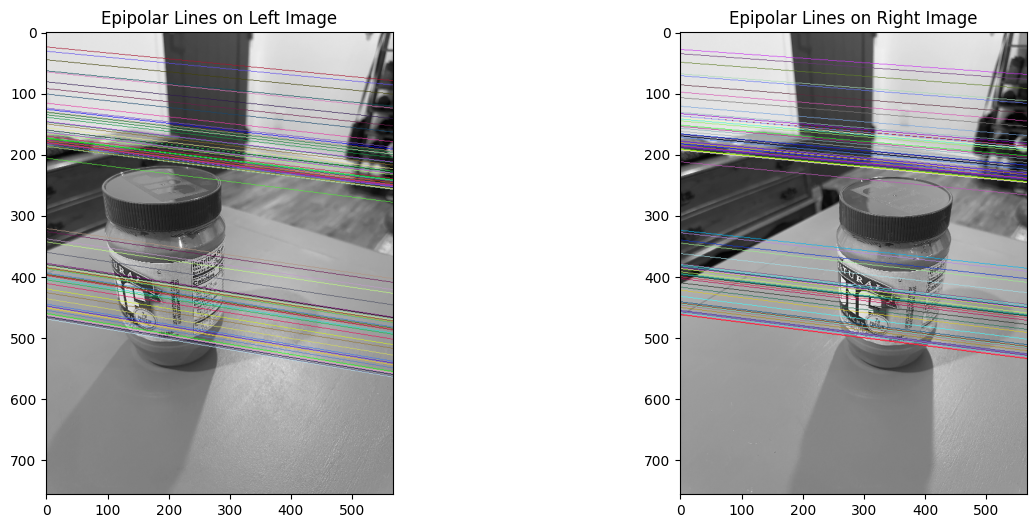

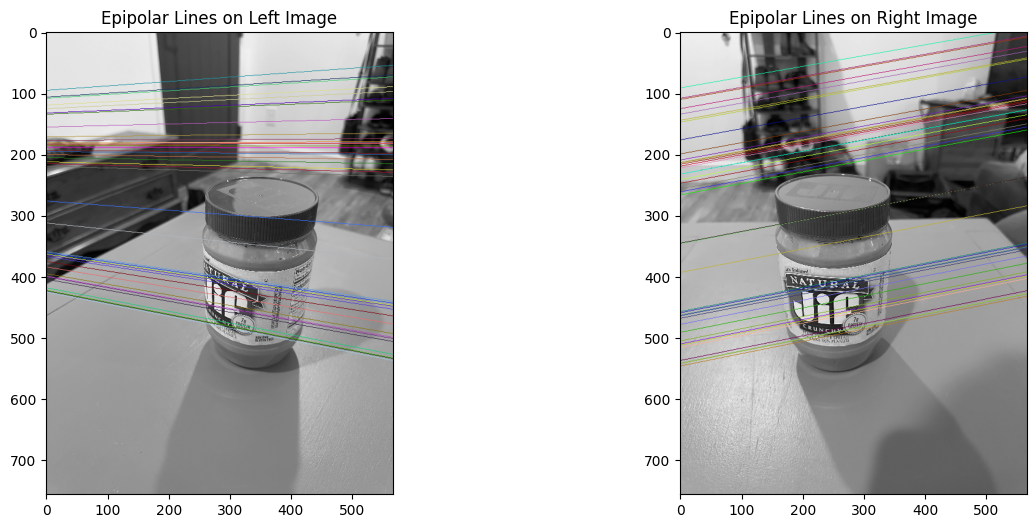

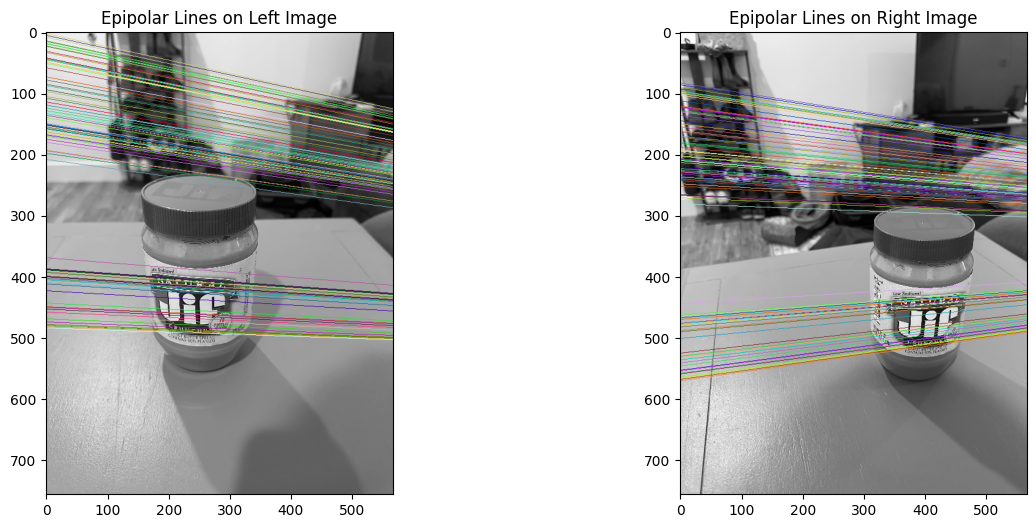

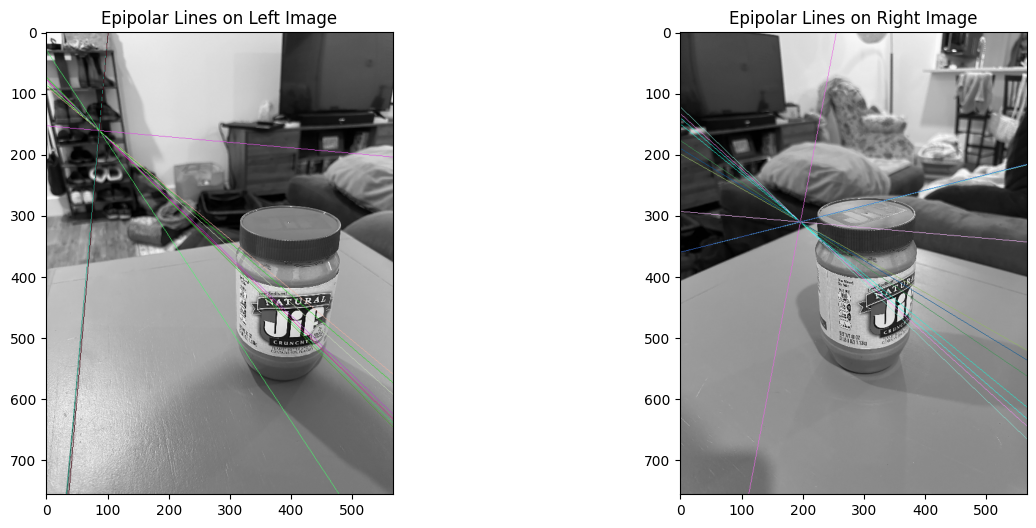

In [10]:
images = [
    cv2.resize(cv2.cvtColor(angle1_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE),
    cv2.resize(cv2.cvtColor(angle2_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE),
    cv2.resize(cv2.cvtColor(angle3_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE),
    cv2.resize(cv2.cvtColor(angle4_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE),
    cv2.resize(cv2.cvtColor(angle5_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE),
]
trajectory, structure = run_sfm(images)

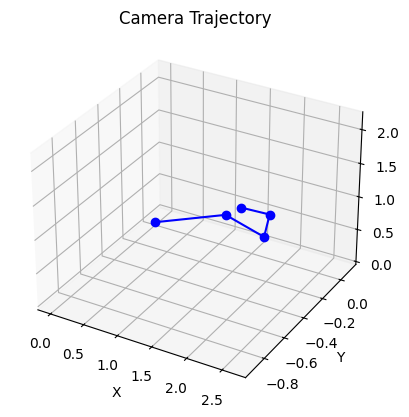

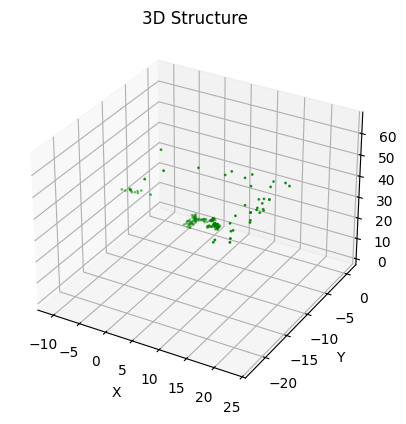

In [11]:
plot_trajectory(trajectory)
plot_structure(structure)

## Task 2 Part 4. Write-up (1–2 paragraphs):
a. Did your reconstruction look realistic?

Answer: The 3D reconstruction with points does not look realistic. There are a lot of matching points due to the large number of distinct features but it does not show a cylindrical shape like the peanut butter jar I pictured. I believe some things in the background are being matched which is interferring with the jar recreation.

b. What kinds of motion caused errors or degenerate configurations?

Answer: When taking the photos I focused on rotating around the image. I needed to incorporate more horizontal differences in my photos to increase the disparity between images. My pipeline was not able to accurately capture the curvature of the object.

c. What were your main failure modes?

Answer: The primary failure mode was the limitation in the number of images and the shape of the object that I photographed. The object has a lot of text which made getting matches across images very easy but the limited number of photos prevented me from being able to capture the rounded shape of the object. I also did not take the photos with enough disparity between images, rotation was the main difference between images.

# Task 3: Calibration Challenge

## Description of Approach:

In order to calibrate my camera I used a chessboard technique where I captured 9 images of the same chessboard from different positions. Using OpenCV's findChessboardCorners I locate the board in each image. Doing this allows me to map 3D object points to 2D correspondences and estimate my camera's intrinsic parameters as well as the distortion coefficients. I use these estimations to compute a new intrinsic matrix K to be used in my pipeline.

The actual process of this involes estimating the phone intrinsics, scaling my intrinsic matrix and images, undistorting the images, and finally using these undistorted images to repeat task 1 and task 2.

In [12]:
calibration_images = [
    cv2.cvtColor(calibration1_img_bgr, cv2.COLOR_BGR2GRAY),
    cv2.cvtColor(calibration2_img_bgr, cv2.COLOR_BGR2GRAY),
    cv2.cvtColor(calibration3_img_bgr, cv2.COLOR_BGR2GRAY),
    cv2.cvtColor(calibration4_img_bgr, cv2.COLOR_BGR2GRAY),
    cv2.cvtColor(calibration5_img_bgr, cv2.COLOR_BGR2GRAY),
    cv2.cvtColor(calibration6_img_bgr, cv2.COLOR_BGR2GRAY),
    cv2.cvtColor(calibration7_img_bgr, cv2.COLOR_BGR2GRAY),
    cv2.cvtColor(calibration8_img_bgr, cv2.COLOR_BGR2GRAY),
    cv2.cvtColor(calibration9_img_bgr, cv2.COLOR_BGR2GRAY),
]

In [13]:
def estimate_phone_intrinsics(
    images,
    pattern_size,
    square_size_m,
):
    objp = np.zeros((pattern_size[0] * pattern_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)
    objp *= square_size_m

    objpoints = []
    imgpoints = []

    for idx, img in enumerate(images):
        found, corners = cv2.findChessboardCorners(img, pattern_size)
        if not found:
            print("Couldn't find chessboard pattern.")
            continue

        criteria = (
            cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
            40,
            1e-5,
        )
        refined = cv2.cornerSubPix(img, corners, (11, 11), (-1, -1), criteria)
        objpoints.append(objp)
        imgpoints.append(
            cv2.cornerSubPix(img, corners, (11, 11), (-1, -1), criteria)
        )

    ret, K_mat, dist_coeffs, _, _ = cv2.calibrateCamera(
        objpoints,
        imgpoints,
        img.shape[::-1],
        None,
        None,
        flags=cv2.CALIB_FIX_K3,
    )

    return K_mat, dist_coeffs

PHONE_K, PHONE_DIST = estimate_phone_intrinsics(
    calibration_images,
    pattern_size=(6, 9),
    square_size_m=0.0173,
)
print("Active camera matrix:\n", PHONE_K)
print("Distortion coefficients:", PHONE_DIST.ravel())

Active camera matrix:
 [[2.86597474e+03 0.00000000e+00 1.49697570e+03]
 [0.00000000e+00 2.86774214e+03 2.03535844e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion coefficients: [ 0.14667367  0.00094354  0.00192333 -0.00229345  0.        ]


In [14]:
def scale_intrinsic_matrix(K_mat, scale_x, scale_y):
    K_resized = K_mat.copy()
    K_resized[0,0] *= scale_x  # f_x
    K_resized[0,2] *= scale_x  # c_x
    K_resized[1,1] *= scale_y  # f_y
    K_resized[1,2] *= scale_y  # c_y
    return K_resized

SCALED_K = scale_intrinsic_matrix(
    PHONE_K,
    IMG_SIZE[0] / ORIGINAL_IMG_SIZE[0], # width
    IMG_SIZE[1] / ORIGINAL_IMG_SIZE[1], # height
)

adj_cam_matrix, roi = cv2.getOptimalNewCameraMatrix(
    SCALED_K, PHONE_DIST, IMG_SIZE, 0, IMG_SIZE
)

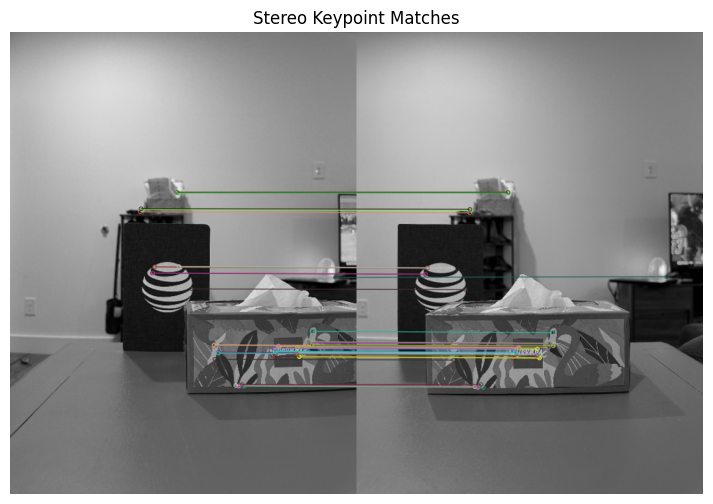

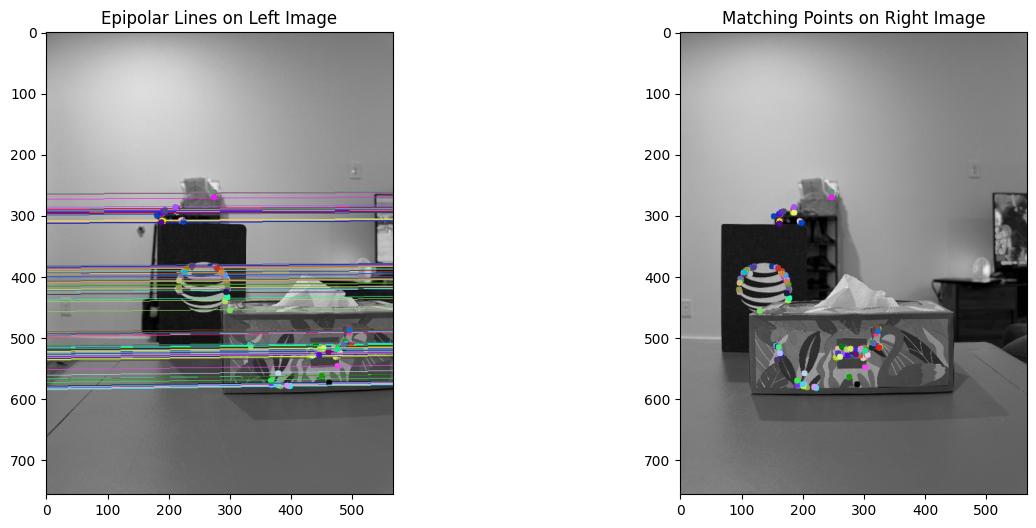

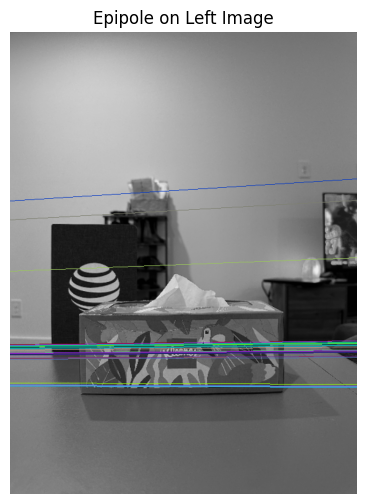

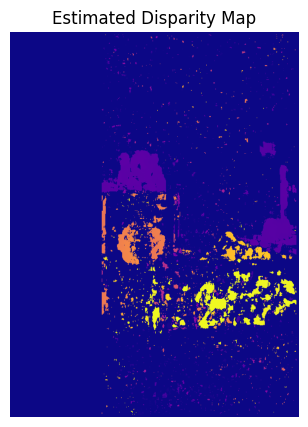

In [15]:
# Re-run Task 1 stereo steps with calibrated intrinsics
left_resized = cv2.resize(
    cv2.cvtColor(left_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE
)
right_resized = cv2.resize(
    cv2.cvtColor(right_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE
)

undistorted_left = cv2.undistort(
    left_resized, SCALED_K, PHONE_DIST, None, adj_cam_matrix
)
undistorted_right = cv2.undistort(
    right_resized, SCALED_K, PHONE_DIST, None, adj_cam_matrix
)


kp1_cal, kp2_cal, matches_cal = match_stereo_keypoints(
    undistorted_left, undistorted_right
)
pts1_cal, pts2_cal, F_cal = estimate_fundamental_matrix_and_draw_epipolar_lines(
    undistorted_left, undistorted_right, matches_cal, kp1_cal, kp2_cal
)
compute_disparity_map(
    undistorted_left, undistorted_right, pts1_cal, pts2_cal, F_cal
)

In [16]:
# Re-run Task 2 SfM with calibrated intrinsics
angle1_resized = cv2.resize(
    cv2.cvtColor(angle1_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE
)
angle2_resized = cv2.resize(
    cv2.cvtColor(angle2_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE
)
angle3_resized = cv2.resize(
    cv2.cvtColor(angle3_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE
)
angle4_resized = cv2.resize(
    cv2.cvtColor(angle4_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE
)
angle5_resized = cv2.resize(
    cv2.cvtColor(angle5_img_bgr, cv2.COLOR_BGR2GRAY), IMG_SIZE
)

undistorted_images = [
    cv2.undistort(
        angle1_resized, SCALED_K, PHONE_DIST, None, adj_cam_matrix
    ),
    cv2.undistort(
        angle2_resized, SCALED_K, PHONE_DIST, None, adj_cam_matrix
    ),
    cv2.undistort(
        angle3_resized, SCALED_K, PHONE_DIST, None, adj_cam_matrix
    ),
    cv2.undistort(
        angle4_resized, SCALED_K, PHONE_DIST, None, adj_cam_matrix
    ),
    cv2.undistort(
        angle5_resized, SCALED_K, PHONE_DIST, None, adj_cam_matrix
    )
]

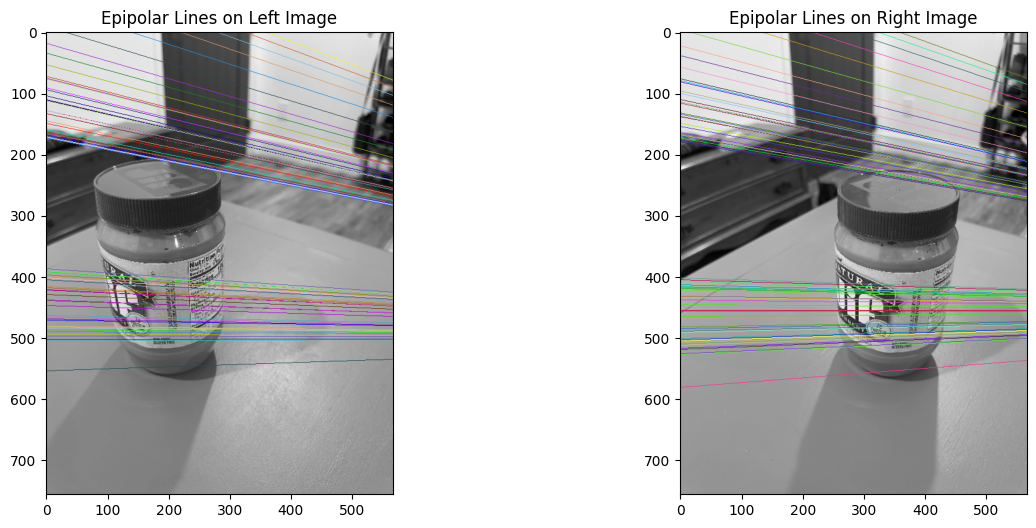

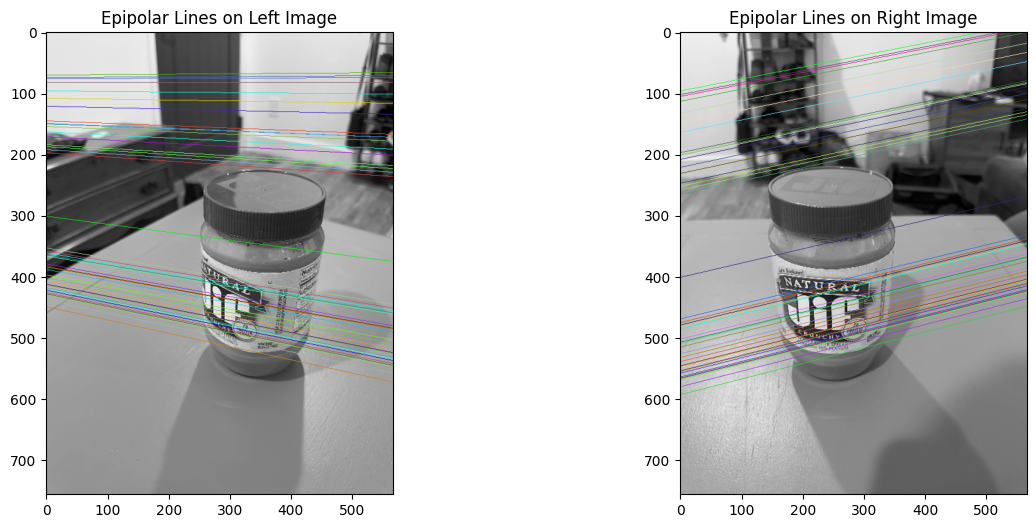

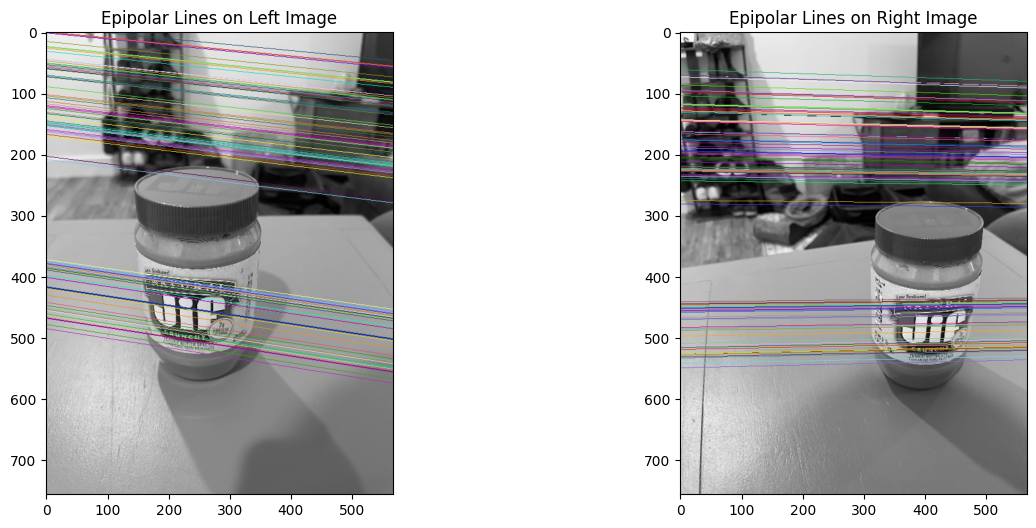

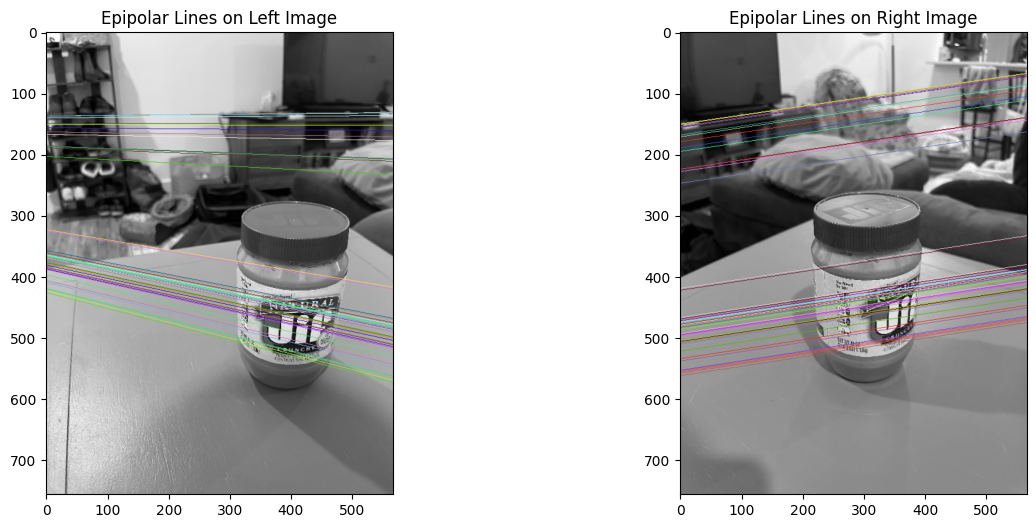

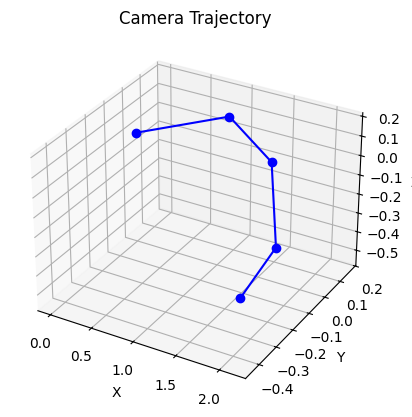

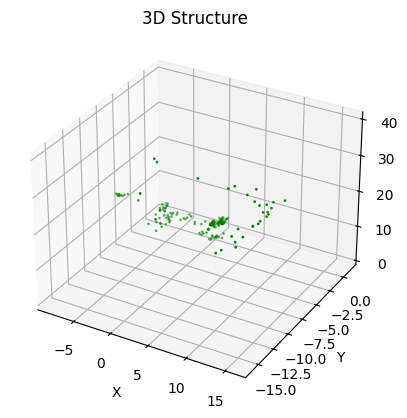

In [17]:
trajectory_cal, structure_cal = run_sfm(undistorted_images, k=SCALED_K)

plot_trajectory(trajectory_cal)
plot_structure(structure_cal)

## Task 3 Part 2a. What changed when using better intrinsics?

Answer: My disparity map for stereo vision was slightly more splotchy but overall had similar accuracy. In this example the calibrated intrinsic matrix made minimal differnce. In my structure from motion pipeline, both runs created a 3D point cloud that did not represent the object very well. I think the primary culprit of this was my images had matches that existed in the background but I did not have access to a space with a plain background. The impact my camera intrinsic calibration had was marginal and shows that my estimated intrinsic values were relatively close to the true values calculated using my calibration technique.

## Task 3 Part 2b. How sensitive is your pipeline to poor calibration?

Answer: While my calibration results didn't show it, my pipeline is very sensitive to poor calibration since inaccuracies in the calibration propagate through the pipeline, effecting the final results. For example, in structure from motion I use my intrinsic matrix K to estimate the pose and triangulate my 3D points to create the 3D point cloud. If the K is poorly calibrated, the 3D representation won't match the true object. If the intrinsics are terribly predicted all the subsequent calculations become distorted.